<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_162_mod2_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter**
Module 2, MNIST Data;
CSC 162, Fall 2025;
November 15, 2025


**DUE: Monday, NOV. 13, 2025**

**INSTRUCTIONS:**

**Overview**

*In this assignment, you will:*

1. Load and preprocess the EMNIST Letters dataset (a handwritten alphabet dataset).

2. Build a Convolutional Neural Network (CNN) using TensorFlow and Keras.

3. Train and evaluate your model on the dataset.

4. Visualize some predictions from the test set.

CNNs are effective in image processing and classification tasks because they automatically learn hierarchical features from raw pixel data. In this task, you will practice using layers such as convolution, pooling, and activation functions to extract meaningful patterns from handwritten letters.

1. If needed, review the following lecture:

2. Video - Introduction to CNNs Using Google Colab Lecture: https://youtu.be/7L0FXpE6Vns

**TASK INSTRUCTIONS:**

**1. Data Loading and Preprocessing**
Objective: Load the EMNIST Letters dataset using TensorFlow Datasets and preprocess the images.



**Objective:** Load the EMNIST Letters dataset using TensorFlow Datasets and preprocess the images.

**Requirements:**

1. Normalize pixel values so that they are between 0 and 1.

2. Reshape images to include a channel dimension (28×28×1) for grayscale.

3. Split the dataset into training and testing sets.

**Starter Code for Loading EMNIST Data:**

**Import packages.**

In [16]:
#python
# Import necessary packages
import tensorflow as tf
from tensorflow.keras import datasets, layers, models #make sure to include "models" because that is used later in the code, when building a sequential cnn
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

**Load the EMNIST dataset.**

In [17]:
# Load the EMNIST Letters dataset.
# This dataset contains 145,600 training images and 14,400 testing images (grayscale, 28x28) (this is how many is supposed to be in the set, but later when I counted the number in the test and train sets my numbers were slightly different).
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # returns tuple (img, label)   #the practice dataset from the lecture had number digits, and it had two components for both train and test (x_train, y_train) and (x_test, y_test) because it was a separate image and a separate label (and we needed both objects). But in this case, each image is a tuple that has an image and a label.
    with_info=True
)


**Preprocess the images.**

In [18]:
# Function to preprocess the images
def preprocess(image, label):
    # Convert image dtype to float32 and scale pixels to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    # Reshape image to (28, 28, 1) for CNN input; in this case we need to reshape to (28, 28, 1) to use batch size of 64 later (instead of the default batch size 32)
    image = tf.expand_dims(image, -1)
    # Adjust label: EMNIST Letters dataset labels are in the range [1, 26]; subtract 1 to get [0, 25]
    label = label - 1
    return image, label

**Apply the preprocessing function** (to the train and test datasets).

In [19]:
# Apply the preprocessing function to the train and test datasets.
ds_train = ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

**Batch and prefetch the datasets** (for training efficiency).

The batch size matters because when I run the model later, the steps_per_epoch = total_number_in_sample / batch_size.

In [20]:
# Batch and prefetch the datasets for training efficiency.
batch_size = 64
ds_train = ds_train.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

**2. Build the CNN Model**
Objective: Create a CNN using TensorFlow Keras.

**Objective:** Create a CNN using TensorFlow Keras.

**Requirements:**

1. Use at least two Conv2D layers with appropriate filter sizes (e.g., 32 and 64 filters) and a kernel size (commonly 3×3).

2. Include MaxPooling2D layers following each convolution to reduce feature map dimensions.

3. Add activation functions (e.g., ReLU) after convolution layers.

4. Flatten feature maps and add one or more Dense (fully connected) layers.

5. Use a final Dense layer with softmax activation to output predictions over 26 classes (representing A–Z).


In [21]:
# Build a Sequential CNN model for Fashion MNIST
full_mnist_model = models.Sequential([
    #Convolutional layer: Applies 32 filters of size 3x3 using ReLU activation.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), #filter size is 3x3

    #Max pooling layer: Reduces spatial dimensions by taking the max value in 2x2 windows.
    layers.MaxPooling2D((2, 2)),   #filter size is 2x2

    #Second convolutional layer: Uses 64 filters to extract more complex features.
    layers.Conv2D(64, (3, 3), activation='relu'),   #use activation functions inside the convolutional layers, in this case define the activation function as Relu.
                                                   #filter size is 3x3
    #Second max pooling layer.
    layers.MaxPooling2D((2, 2)),  #filter dize is 2x2

    #Flatten the feature maps into a 1D vector.
    layers.Flatten(),   #must have a flattening layer and this is the only flattening layer in this model

    #Dense layer: Learns a complex representation from features.
    layers.Dense(64, activation='relu'), #use activation functions inside the convolutional layers, in this case define the activation function as Relu.

    #Output layer: Produces 26 class probabilities via softmax activation.
    layers.Dense(26, activation='softmax') #make sure to define the number of classes produced as 26 (and not 10 as in the practice mnist digits dataset from the lecture) because there are more letters (and thus classes) than digits from the other dataset.
])



**3. Model Compilation and Training**

**Steps:**

1. Compile the model using the Adam optimizer and the sparse categorical cross-entropy loss (since labels are integers in the range [0, 25]).

2. Train your model for about 10–20 epochs.

3. Use part of the training data for validation (e.g., set validation_split if using non-dataset pipeline or create a separate validation set).

1. Compile the model

In [22]:
#Compile the model with the Adam optimizer and sparse categorical cross-entropy loss
full_mnist_model.compile(optimizer='adam',                    #a model must be compiled before it is trained and before model.fit (running the model).
                      loss='sparse_categorical_crossentropy',   #we defined how the loss is calculated to be a method called 'sparce_categorical_crossentropy" since that is what method was used in the video lecture, but there are other methods, depending on the type of model and data
                      metrics=['accuracy'])       #here we are defining the metric to be accuracy, but could possibly be F1 Score, Confusion Matrix, etc. if we wanted (but I chose Accuracy).



2. Validation (using part of the training data).

Due to the type of data structure, the validation split had to be done on teh training data prior to running the model.fit, whereas on the mnist digits data, the validation split was a set as a paramenter when running the model.fit because it had a different data structure.

In [23]:
#Python
#First, split the data into train and validation before the doing the model fit step (using 10% of data as validation).
TRAIN_SIZE = int(0.9 * ds_info.splits['train'].num_examples) # 90% for training
VALIDATION_SIZE = ds_info.splits['train'].num_examples - TRAIN_SIZE # 10% for validation

ds_train_subset = ds_train.take(TRAIN_SIZE) #.repeat()
ds_validation_subset = ds_train.skip(TRAIN_SIZE).take(VALIDATION_SIZE)

3. Train the model (10-20 epochs).

Count the number of image in the training data total, the training only, and the validation.

In [24]:
#TOTAL NUMBER TRAINING SAMPLES (prior to splitting off part of validation)
ds_info.splits['train'].num_examples    # 88,800 is the total number of images (BEFORE splitting of part of the training set for validation)

#Training set size - Print the size
print(f"Training set size: {TRAIN_SIZE}") #training set size: 79,920

#Validation set size - Print the size
print(f"Validation set size: {VALIDATION_SIZE}") #validation set size: 8,880

#BATCH SIZE
#batch_size =    #if you are using data generators or tf.data.Dataset objects (which already generate batches), you should not specify the batch size
#in model.fit(), as the batch size is determined by how the dataset or generator was configured.
#default batch size is 32 (in keras), but earlier in the code we opted to set batch size = 64.

#STEPS PER EPOCH
#steps_per_epoch = total_number_of_training_samples / batch_size
steps_per_epoch = 88880 / 64
print(f"Steps per epoch: {steps_per_epoch}") #steps per epoch: 1388.75. The computer (without me specifiying the steps_per_epoch inside the model) was alreaady using 1388, so I got basically the same number of steps_per_epoch.



Training set size: 79920
Validation set size: 8880
Steps per epoch: 1388.75


In [ ]:
#Train the full MNIST model for 10 epochs (using 10% of data as validation); pass the validation subset in to the model "fit" using the validation_data instead of validation_split (because I already split the data prior to the "fit" command in the model.)
#full_mnist_model.fit(ds_train, epochs=10, validation_split=0.1) #not using this one - this was from the practice during the lecture using mnist digits data.

full_mnist_model.fit(ds_train_subset, epochs=10, validation_data=ds_validation_subset)
#full_mnist_model.fit(ds_train_subset, epochs=12, steps_per_epoch = 1388, validation_data=ds_validation_subset) #don't need to specify the steps_per_epoch because I would specify the same number that the model was alread doing without me specifying it.

Epoch 1/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 78s 56ms/step - accuracy: 0.7789 - loss: 0.7256
Epoch 2/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.8987 - loss: 0.3138
Epoch 3/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 83s 60ms/step - accuracy: 0.9178 - loss: 0.2473
Epoch 4/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 136s 55ms/step - accuracy: 0.9293 - loss: 0.2092
Epoch 5/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 69s 50ms/step - accuracy: 0.9359 - loss: 0.1848
Epoch 6/10
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.9419 - loss: 0.1649
Epoch 7/10
 311/1388 ━━━━━━━━━━━━━━━━━━━━ 49s 46ms/step - accuracy: 0.9479 - loss: 0.1424

Below is a screen shot of the epochs output when the model was doing 10 epochs, the first time I ran the model.
You can see that each epoch gradually increased in accuracy, with the first epoch having smallest accuracy (but in this case, still pretty high!) of all the epochs, and the last epoch having the highest accuracy.


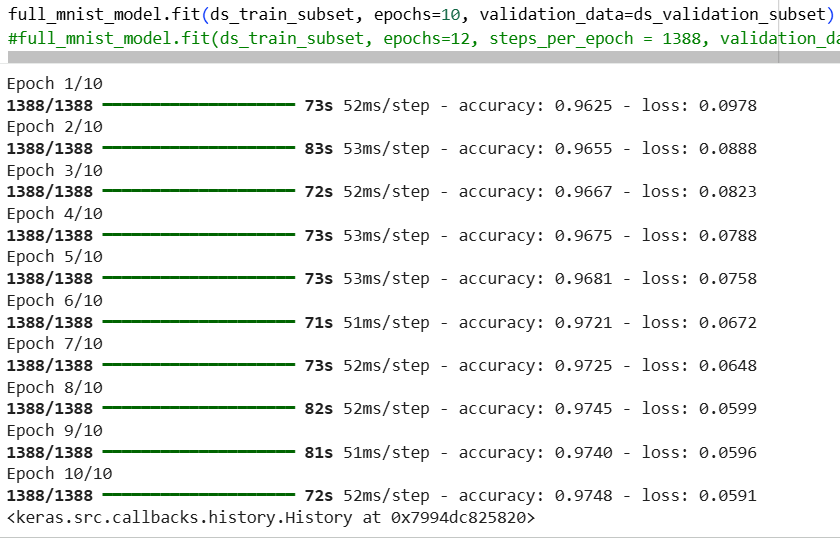

In [105]:
#Print the model summary to review the architecture and number of parameters
full_mnist_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 368,912 (1.41 MB)

 Trainable params: 122,970 (480.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 245,942 (960.71 KB)

Below is a screenshot of the model summary after the model did 10 epochs, the first time I ran the model. You can see the number of parameters for each layer of the model (the first time it was run), as well as the shape for each layer. The max pooling and flattening layers had 0 parameters and the first dense layer had the highest number of parameters, followed by the second convolutional layer, followed by (drastically lower) the last dense layer, followed by the first convolutional layer as the lowest number of parameters that wasn't 0.

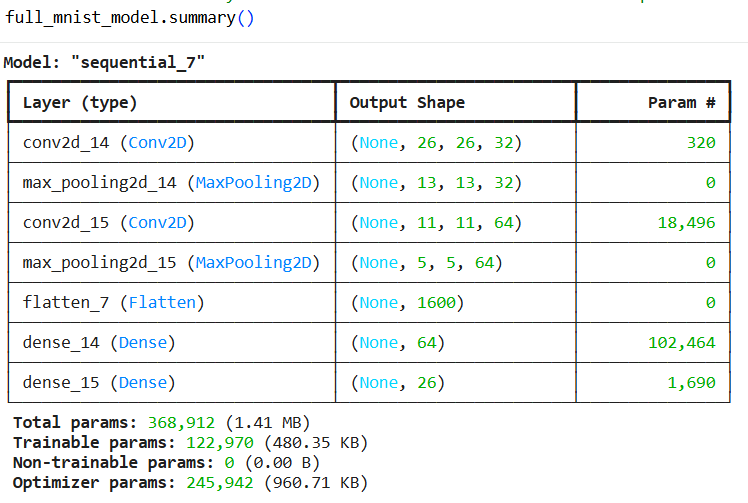

**4. Evaluation and Visualization**

**Tasks:**

1. Evaluate your trained model using the test set and report the test accuracy.

2. Display a few sample test images with their predicted class labels using Matplotlib.

3. Comment on your model’s performance and any observations.

1a. Evaluate trained model on test set.

I am looking to evaluate the model using the loss and accuracy from the test data.

In [106]:
#Evaluate the model on the test set
test_loss_f, test_acc_f = full_mnist_model.evaluate(ds_test, verbose=2)
print("Full MNIST Test Accuracy:", test_acc_f)

232/232 - 9s - 38ms/step - accuracy: 0.9096 - loss: 0.4249
Full MNIST Test Accuracy: 0.9095945954322815


1b. Report the test accuracy.

Here, the first time I ran the model, the model accuracy with test data (afte the model was trained and validated used training data) was 0.90959 which is **90.96%**, and it is **close to 91% accuracy** (when the model did 10 epochs). Below is a screenshot.

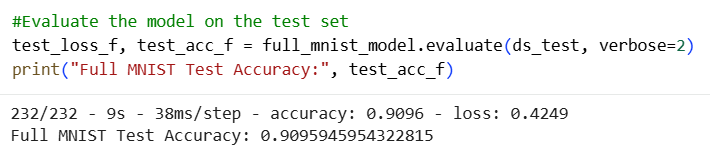

2. Display test images with predicted class labels.

First, find out how many test images are in the testing set.

In [141]:
#how many images are in the Test set
print(f"Testing set size: {ds_test.cardinality().numpy()}")
#print(f"Type {type(ds_test)}")      #14,800 images in the Test set

#Two different WAYS to determine size of Test set

#1) determine size of test set from test set object
size_test = {ds_test.cardinality().numpy().item()}
print(f"size of TEST set: {size_test}")

#2) determine size of test set from the ds_info
TEST_SIZE = int(1 * ds_info.splits['test'].num_examples)
print(f"TEST set size: {TEST_SIZE}")    #14,800 images in the test set, verified a different way

Testing set size: 14800
size of TEST set: {14800}
TEST set size: 14800


Next, work on taking a random sample image (from test data) and making a prediction.

In [1]:
# Make a prediction on a random sample image from the Full MNIST test set
#how to pick a random number
#print(f"random number = {np.random.randint(0, 10)}")
#print(f"random number = {np.random.randint(0, 10)}")
#print(f"random number = {np.random.randint(0, 10)}")
#print(f"random number = {np.random.randint(0, 10)}") #each one prints a random number, in this test they were all different


sample_index_f = np.random.randint(0, TEST_SIZE) #used TEST_SIZE (which is an integer) from above that calculated the size of the test set to be 14800 images
print(f"type of sample_index_f: {type(sample_index_f)}")
print(f"sample_index_f: {sample_index_f}")

sample_image_f, _ = ds_test[sample_index_f]
prediction_f = full_mnist_model.predict(sample_image_f[np.newaxis, ...])
predicted_class_f = np.argmax(prediction_f, axis=1)
print("Predicted class for Full MNIST sample:", predicted_class_f[0])

NameError: name 'np' is not defined

Make a prediction on a random sample image from the Full MNIST test set.

One issue came up when trying to do sample_image_f = ds_test[sample_index_f], it wasn't able to pull anything from ds_test using the square brackets and got an error. This is because the data type was different for the mnist digits data we practiced on in lecture vs the data now (the full letters mnist dataset). Tesnsorflow datasets give out something called a tuple which is a pair that has an image and a label (image, label). The code from the practice assignment with mnist digits a tuple to sample_image_f but it gets messed up when model.predict() is used because it gets a tuple instead of an image array. The model needs a single input tensor. I made two changes. First I made the ds_train data into a list (prior to doing the random sampling). Making it into a list stored it into memory in Python so it could be indexed before doing the random sample, but I read that this only works if the dataset is small enough (to be stored into memory). If it was a really, really large dataset, another method would have to be used if there wasn't enough memory. Second, I then did sample_image_f, _ = ds_test_list[sample_index_f] (where there is a comma then a blank before the equals sign) to show that we don't care what the second part of the tuple is when doing the sample. The blank is placeholder for something that I'm not planning to use. But later I changed my mind and wanted to use it. Next, I actually just changed the "_" (the blank) to sample_label because I decided I did want to see the label for the random sample.


In [3]:
# Make a prediction on a random sample image from the Full MNIST test set

#make sure numpy and tensorflow are imported and running
import numpy as np
import tensorflow as tf

#how to pick a random number - test to see if it's working, and print out the randomly selected numbers
#print(f"random number = {np.random.randint(0, 10)}")
#print(f"random number = {np.random.randint(0, 10)}")
#print(f"random number = {np.random.randint(0, 10)}")
#print(f"random number = {np.random.randint(0, 10)}") #each one prints a random number, in this test they were all different

#TEST_SIZE is defined and ds_test is the dataset object
TEST_SIZE = 14800 #(from calculations above)

#when pulling from ds_test[sample_index_f], this doesn't work as it did for the practice mnist digits dataset we did in the lecture so must convert to a list first
# Convert the dataset object to a list to enable indexing; it doesn't work without making it a list first to do random samples from
ds_test_list = list(ds_test) #

sample_index_f = np.random.randint(0, TEST_SIZE)
print(f"type of sample_index_f: {type(sample_index_f)}")
print(f"sample_index_f: {sample_index_f}")

# Index the list instead of the dataset object
sample_image_f, sample_label = ds_test_list[sample_index_f]

prediction_f = full_mnist_model.predict(sample_image_f[np.newaxis, ...])
predicted_class_f = np.argmax(prediction_f, axis=1)
print(f"Predicted class for Full MNIST sample: {predicted_class_f[0]}")
print(f"Label for Full MNIST sample: {sample_label}")

NameError: name 'ds_test' is not defined

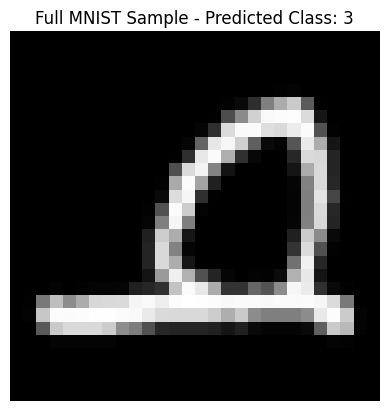

In [152]:
# Display the sample image with predicted class
tf.experimental.numpy.experimental_enable_numpy_behavior()

plt.imshow(sample_image_f, cmap='gray')
plt.title("Full MNIST Sample - Predicted Class: {}".format(predicted_class_f[0]))
plt.axis('off')
plt.show()

3. Comment on my model's performance (and any observations).

COMMENTS:

The sample images outputted each time a run a random sample, make a prediction, then display the image of the sample image - they appear rotated 90 degrees and inverted or reflected (like a mirror opposite). Online some people commented that they needed to do some operations to rotate and reflect the images so the display image appears to look like the proper orientation of the letter.

**5. Documentation and Submission**

**1. Documentation:** Ensure that your Colab notebook is well-documented. Include comments in each code cell explaining what each section of code is doing.


**2. File Submission:** When you have completed the assignment, save your Google Colab notebook as a .ipynb file and upload it to Brightspace as your assignment submission. (Example SmithMod02.ipynb)